# BIRCH from Scratch

BIRCH - Balanced Iterative Reducing and Clustering using Hierarchies - clusters a dataset by
reading it **once** and never keeping the points.

Instead of the data it keeps small numerical summaries, arranged in a height-balanced tree. Each
summary is three numbers: how many points went into it, their vector sum, and the sum of their
squared lengths. From those three numbers alone the centroid, the radius and the diameter of the
group can be recovered exactly, so once a point has been folded into a summary it is never needed
again.

That is what makes the algorithm cheap. A point is inserted by walking from the root down to a
leaf, comparing itself only against the handful of child summaries at each level, so the work per
point is fixed and the total cost is $O(n)$. The methods that compare every point against every
other point cost $O(n^2)$.

The dataset here is UCI Skin Segmentation: **245,057 pixels** in blue/green/red space, labelled
skin or not-skin. The number is the point of the notebook. `mean_shift_from_scratch.ipynb` in this
repository uses the same dataset and has to cut it down to **800 rows**, because every pass of Mean
Shift measures all points against all points. On the full file that would be

$$\frac{245{,}057 \times 245{,}056}{2} \approx 3.0 \times 10^{10}$$

pairwise distances **per pass**, which is why the attempt is not made there. BIRCH clusters all
245,057 rows, holds a few thousand summaries in memory while doing it, and finishes in seconds.

The label is held back and used only at the end, to score the clusters.

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import style
from matplotlib.patches import Circle
from ucimlrepo import fetch_ucirepo

style.use('ggplot')

blue, orange, green = '#2a78d6', '#eb6834', '#1baf7a'
colors = 10 * [blue, orange, green, '#eda100', '#4a3aa7']

np.random.seed(0)
rng = np.random.default_rng(0)

## Loading the data

`fetch_ucirepo(id=229)` downloads all 245,057 pixels. Each row has a blue, green and red value in
$[0, 255]$ and a label of `1` for skin or `2` for not-skin.

Two things happen to the data before it is clustered.

The rows are **shuffled** with a fixed seed. BIRCH reads the file once, so the order of arrival
changes which entries a point lands in; the file as shipped is grouped by image, and shuffling
removes that.

The three channels are then standardised, $x \leftarrow (x - \mu)/\sigma$ per channel, so the
`threshold` on cluster radius means the same thing in every direction.

Nothing is subsampled. `X` holds all 245,057 rows and every later cell uses all of them.

In [2]:
skin = fetch_ucirepo(id=229)

X_raw = skin.data.features.values.astype(float)
y_raw = skin.data.targets.values.ravel()
feature_names = list(skin.data.features.columns)

# one pass means order matters, so fix an order once
order = rng.permutation(len(X_raw))
X_raw = X_raw[order]
y = y_raw[order]

# same scale on every channel, so one radius threshold fits all three
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)

baseline = (y == 2).mean()

print('rows:', X.shape[0], ' features:', feature_names)
print('skin (1):    ', int((y == 1).sum()))
print('not-skin (2):', int((y == 2).sum()))
print()
print(f'majority-class baseline (call everything not-skin): {baseline:.4f}')
print()
print('storing the raw points costs', X.nbytes / 1e6, 'MB')

rows: 245057  features: ['B', 'G', 'R']
skin (1):     50859
not-skin (2): 194198

majority-class baseline (call everything not-skin): 0.7925

storing the raw points costs 5.881368 MB


## What the data looks like

The cell plots the pixels in two of the three channel planes, coloured by the true label.

Only 8,000 randomly chosen rows are drawn - 245,057 overlapping markers would be a solid block of
colour. **The subsample is for the picture only.** Every clustering step below runs on the full
array.

The shape matters for what comes later. Both classes form long diagonal bands rather than round
blobs: colour channels are strongly correlated, so brightening a pixel moves it along the band. The
skin band is narrower and sits off to one side, but it lies inside the not-skin band rather than
away from it.

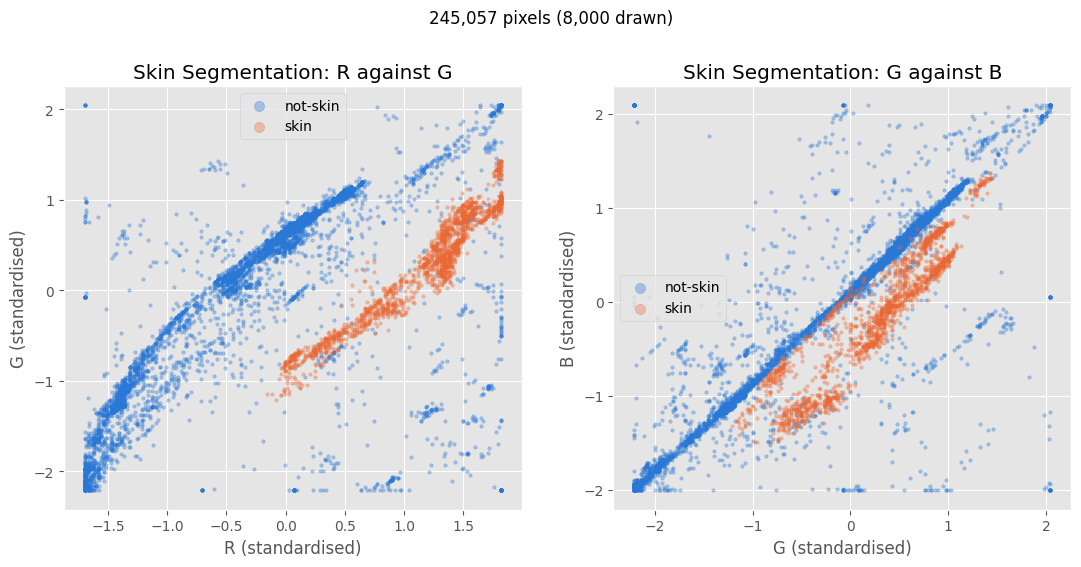

both classes are elongated bands, not spheres:
  skin      spread per channel [0.67 0.6  0.52]
  not-skin  spread per channel [1.06 1.07 0.88]


In [3]:
plot_idx = rng.choice(len(X), 8000, replace=False)
Xp, yp = X[plot_idx], y[plot_idx]

fig, ax = plt.subplots(1, 2, figsize=(13, 5.5))

for a, (i, j) in zip(ax, [(2, 1), (1, 0)]):
    for label, color, name in [(2, blue, 'not-skin'), (1, orange, 'skin')]:
        m = yp == label
        a.scatter(Xp[m, i], Xp[m, j], color=color, s=6, alpha=0.35, label=name)
    a.set_xlabel(feature_names[i] + ' (standardised)')
    a.set_ylabel(feature_names[j] + ' (standardised)')
    a.legend(markerscale=3)

ax[0].set_title('Skin Segmentation: R against G')
ax[1].set_title('Skin Segmentation: G against B')
fig.suptitle('245,057 pixels (8,000 drawn)', y=1.02)
plt.show()

print('both classes are elongated bands, not spheres:')
for label, name in [(1, 'skin'), (2, 'not-skin')]:
    c = X[y == label]
    c = c - c.mean(axis=0)
    sd = np.sqrt((c ** 2).sum(axis=0) / len(c))
    print(f'  {name:9s} spread per channel {np.round(sd, 2)}')

## The Clustering Feature

Everything BIRCH stores is the **Clustering Feature**, a triple summarising a set of points
$\{x_1, \dots, x_N\}$ in $d$ dimensions:

$$CF = \left(N,\ \vec{LS},\ SS\right), \qquad
\vec{LS} = \sum_{i=1}^{N} x_i, \qquad
SS = \sum_{i=1}^{N} \lVert x_i \rVert^2$$

Here $d = 3$, so a CF is five floating point numbers: one count, a three-vector, one scalar. It
does not grow with $N$.

**Additivity.** If two disjoint sets have $CF_1$ and $CF_2$, the summary of their union is

$$CF_1 + CF_2 = \left(N_1 + N_2,\ \vec{LS}_1 + \vec{LS}_2,\ SS_1 + SS_2\right)$$

Merging two summaries is addition, nothing more. This is the property the whole structure rests on:
a point can be absorbed by adding $(1, x, \lVert x \rVert^2)$, a node's summary is the sum of its
children's, and two clusters can be merged in the global step without revisiting a single point.

**Centroid.**

$$\vec{c} = \frac{\vec{LS}}{N}$$

**Radius.** The radius is the root-mean-square distance from the points to their own centroid.
Expanding the square,

$$R^2 = \frac{1}{N}\sum_{i=1}^{N} \lVert x_i - \vec{c} \rVert^2
      = \frac{1}{N}\sum_{i=1}^{N}\left(\lVert x_i \rVert^2 - 2\, x_i \cdot \vec{c} + \lVert \vec{c} \rVert^2\right)
      = \frac{SS}{N} - 2\,\vec{c} \cdot \frac{\vec{LS}}{N} + \lVert \vec{c} \rVert^2$$

The cross-term is where the individual points disappear: $\sum_i x_i$ is exactly $\vec{LS}$, and
$\vec{LS}/N$ is $\vec{c}$ itself, so that middle term is $-2\lVert \vec{c} \rVert^2$ and collapses
against the last one, leaving

$$R = \sqrt{\frac{SS}{N} - \left\lVert \frac{\vec{LS}}{N} \right\rVert^2}$$

No $x_i$ appears. The summary is sufficient.

**Diameter.** The same cancellation applied to the average distance between all pairs within the
set gives

$$D = \sqrt{\frac{2N\,SS - 2\lVert \vec{LS} \rVert^2}{N(N-1)}}$$

**Inter-cluster distance.** For the global step two summaries have to be compared. The average
distance between a point of one set and a point of the other is

$$D_2 = \sqrt{\frac{N_2\, SS_1 + N_1\, SS_2 - 2\, \vec{LS}_1 \cdot \vec{LS}_2}{N_1 N_2}}
      = \sqrt{\frac{SS_1}{N_1} + \frac{SS_2}{N_2} - 2\,\vec{c}_1 \cdot \vec{c}_2}$$

which rearranges to $D_2^2 = \lVert \vec{c}_1 - \vec{c}_2 \rVert^2 + R_1^2 + R_2^2$: the distance
between the centroids, inflated by how wide the two clusters are. Again computed from the triples
only.

The next cell checks all four formulas numerically against the definitions they came from, on a
random block of the real data.

In [4]:
def cf_of(points):
    # the triple: count, linear sum, sum of squares
    return len(points), points.sum(axis=0), (points ** 2).sum()


def cf_centroid(N, LS, SS):
    return LS / N


def cf_radius(N, LS, SS):
    return np.sqrt(max(SS / N - ((LS / N) ** 2).sum(), 0.0))


def cf_diameter(N, LS, SS):
    return np.sqrt(max((2 * N * SS - 2 * (LS ** 2).sum()) / (N * (N - 1)), 0.0))


def cf_d2(cf1, cf2):
    N1, LS1, SS1 = cf1
    N2, LS2, SS2 = cf2
    return np.sqrt(max(SS1 / N1 + SS2 / N2 - 2 * (LS1 / N1) @ (LS2 / N2), 0.0))


A = X[rng.choice(len(X), 500, replace=False)]
B = X[rng.choice(len(X), 300, replace=False)]
cfA, cfB = cf_of(A), cf_of(B)

# radius, straight from the points and then from the triple alone
direct_R = np.sqrt(((A - A.mean(axis=0)) ** 2).sum(axis=1).mean())
direct_D = np.sqrt((((A[:, None, :] - A[None, :, :]) ** 2).sum(2)).sum() / (len(A) * (len(A) - 1)))
direct_D2 = np.sqrt(((A[:, None, :] - B[None, :, :]) ** 2).sum(2).mean())

print('centroid  from points', np.round(A.mean(axis=0), 6))
print('          from CF    ', np.round(cf_centroid(*cfA), 6))
print(f'radius    from points {direct_R:.10f}')
print(f'          from CF     {cf_radius(*cfA):.10f}')
print(f'diameter  from points {direct_D:.10f}')
print(f'          from CF     {cf_diameter(*cfA):.10f}')
print(f'D2        from points {direct_D2:.10f}')
print(f'          from CF     {cf_d2(cfA, cfB):.10f}')

# additivity: the summary of the union is the sum of the summaries
union = cf_of(np.vstack([A, B]))
added = (cfA[0] + cfB[0], cfA[1] + cfB[1], cfA[2] + cfB[2])
print()
print('CF(A union B) == CF(A) + CF(B):',
      union[0] == added[0],
      np.allclose(union[1], added[1]),
      np.isclose(union[2], added[2]))
print()
print('500 points stored directly:', A.nbytes, 'bytes')
print('the same 500 points as a CF:', 5 * 8, 'bytes')

centroid  from points [-0.005131  0.033211  0.011698]
          from CF     [-0.005131  0.033211  0.011698]
radius    from points 1.7563773430
          from CF     1.7563773430
diameter  from points 2.4863802839
          from CF     2.4863802839
D2        from points 2.4920589400
          from CF     2.4920589400

CF(A union B) == CF(A) + CF(B): True True True

500 points stored directly: 12000 bytes
the same 500 points as a CF: 40 bytes


## The CF-tree

The tree is height-balanced and holds CF entries, not points.

- A **leaf node** holds up to `branching_factor` CF entries. Each entry is a sub-cluster of points
  whose radius is at most `threshold`.
- A **non-leaf node** holds up to `branching_factor` entries too, but each of its entries is the
  sum of the CFs in the child below it, and it carries a pointer to that child.

`Node` is that structure: `leaf` says which kind it is, `cfs` is the list of five-number entries
`[N, LS0, LS1, LS2, SS]`, and `children` is the parallel list of child nodes, empty for a leaf.

`BIRCH.build` inserts one point at a time and does four things per point.

1. **Descend.** From the root, compare the point against the centroid $\vec{LS}/N$ of each entry in
   the node and step into the closest child. The comparison count per level is at most
   `branching_factor`, so the descent costs $O(\text{depth} \times \text{branching\_factor})$
   regardless of how many points have already been read.
2. **Absorb or start a new entry.** At the leaf, take the closest entry and work out what its
   radius would become if the point joined it, using
   $R^2 = SS/N - \lVert \vec{LS}/N \rVert^2$ on the widened triple. If that stays at or below
   `threshold`, add $(1, x, \lVert x \rVert^2)$ into the entry. Otherwise the point becomes a new
   entry of its own with $N = 1$.
3. **Update the path.** The same $(1, x, \lVert x \rVert^2)$ is added to every entry on the way back
   up, keeping each non-leaf entry equal to the sum of its subtree. This is additivity used directly.
4. **Split if full.** If the leaf now holds more than `branching_factor` entries, `BIRCH.split`
   takes the two entries whose centroids are farthest apart as seeds and sends every other entry to
   the nearer seed, producing two nodes. The parent replaces the old entry with one of them and
   appends the other, which can overflow the parent in turn, so splits propagate upward. If the root
   splits, a new root is made above it and the tree grows one level.

`BIRCH.collect` then walks the finished tree, stacks the leaf entries into arrays `N`, `LS`, `SS`,
and derives `centroids` and `radii` from them. It also records the entry and node count per level,
which is the shape of the tree.

Nothing in any of this needs a second look at the data.

## The global clustering step

The leaves are a few thousand small sub-clusters, each capped at radius `threshold`. That is a
summary of the data, not a clustering of it, so a second stage groups the leaf entries into the
final clusters.

`BIRCH.global_step` runs agglomerative clustering over the leaf entries. Every entry starts as its
own cluster, and the closest pair is merged repeatedly. Closeness is the $D_2$ above,

$$D_2^2(i, j) = \frac{SS_i}{N_i} + \frac{SS_j}{N_j} - 2\,\vec{c}_i \cdot \vec{c}_j$$

so an entry holding 8,000 pixels pulls on the result 8,000 times as hard as a singleton - the
weighting by $N$ is already inside the triple. The merge itself is `N[i] += N[j]`,
`LS[i] += LS[j]`, `SS[i] += SS[j]`; additivity again, and the reason no points are needed here
either.

The distance matrix over $L$ leaf entries is built once. After each merge only one row and column
change, so `rowmin` and `rowarg` cache each row's nearest neighbour and only the rows whose nearest
neighbour was one of the two merged clusters are recomputed. The whole merge order is stored in
`merges`, so `labels_for_k` can replay it and read off a grouping for any $k$ without redoing the
work.

`BIRCH.nearest_entry` then assigns the original points: each row goes to the leaf entry with the
closest centroid, computed in blocks of 20,000 rows so the distance block never exceeds
$20{,}000 \times L$. `BIRCH.predict` maps that through `entry_label` to give the final cluster.
The full 245,057 rows are only touched again here, and only against the $L$ centroids, not against
each other.

In [5]:
class Node:
    __slots__ = ('leaf', 'cfs', 'children')

    def __init__(self, leaf):
        self.leaf = leaf
        self.cfs = []
        self.children = []


class BIRCH:
    def __init__(self, threshold=0.1, branching_factor=10, n_clusters=2):
        self.threshold = threshold
        self.branching_factor = branching_factor
        self.n_clusters = n_clusters

    # the CF of a whole node is the sum of the CFs it holds
    def node_cf(self, node):
        n = l0 = l1 = l2 = ss = 0.0
        for c in node.cfs:
            n += c[0]; l0 += c[1]; l1 += c[2]; l2 += c[3]; ss += c[4]
        return [n, l0, l1, l2, ss]

    # split an overfull node, seeding with the two farthest entries
    def split(self, node):
        cfs = node.cfs
        m = len(cfs)
        cen = [(c[1] / c[0], c[2] / c[0], c[3] / c[0]) for c in cfs]
        far = -1.0
        a = b = 0
        for i in range(m):
            xi, yi, zi = cen[i]
            for j in range(i + 1, m):
                xj, yj, zj = cen[j]
                d = (xi - xj) ** 2 + (yi - yj) ** 2 + (zi - zj) ** 2
                if d > far:
                    far = d
                    a, b = i, j
        left = Node(node.leaf)
        right = Node(node.leaf)
        ca, cb = cen[a], cen[b]
        for i in range(m):
            xi, yi, zi = cen[i]
            da = (xi - ca[0]) ** 2 + (yi - ca[1]) ** 2 + (zi - ca[2]) ** 2
            db = (xi - cb[0]) ** 2 + (yi - cb[1]) ** 2 + (zi - cb[2]) ** 2
            side = left if da <= db else right
            side.cfs.append(cfs[i])
            if not node.leaf:
                side.children.append(node.children[i])
        return left, right

    # the single pass: read each point once, keep only summaries
    def build(self, rows):
        thr2 = self.threshold ** 2
        B = self.branching_factor
        root = Node(True)

        for p0, p1, p2 in rows:
            q = p0 * p0 + p1 * p1 + p2 * p2
            path = []
            node = root

            # descend, always into the closest child centroid
            while not node.leaf:
                cfs = node.cfs
                best = 1e300
                bi = 0
                for i in range(len(cfs)):
                    c = cfs[i]
                    inv = 1.0 / c[0]
                    d = (c[1] * inv - p0) ** 2 + (c[2] * inv - p1) ** 2 + (c[3] * inv - p2) ** 2
                    if d < best:
                        best = d
                        bi = i
                path.append((node, bi))
                node = node.children[bi]

            # at the leaf, the closest entry
            cfs = node.cfs
            best = 1e300
            bi = -1
            for i in range(len(cfs)):
                c = cfs[i]
                inv = 1.0 / c[0]
                d = (c[1] * inv - p0) ** 2 + (c[2] * inv - p1) ** 2 + (c[3] * inv - p2) ** 2
                if d < best:
                    best = d
                    bi = i

            # absorb only if R = sqrt(SS/N - ||LS/N||^2) stays under threshold
            absorbed = False
            if bi >= 0:
                c = cfs[bi]
                n = c[0] + 1.0
                l0 = c[1] + p0
                l1 = c[2] + p1
                l2 = c[3] + p2
                ss = c[4] + q
                r2 = ss / n - (l0 * l0 + l1 * l1 + l2 * l2) / (n * n)
                if r2 <= thr2:
                    c[0] = n; c[1] = l0; c[2] = l1; c[3] = l2; c[4] = ss
                    absorbed = True
            if not absorbed:
                cfs.append([1.0, p0, p1, p2, q])

            # additivity: the point joins every CF on the path back to the root
            for nd, i in path:
                c = nd.cfs[i]
                c[0] += 1.0; c[1] += p0; c[2] += p1; c[3] += p2; c[4] += q

            # split upward while nodes are over the branching factor
            if len(node.cfs) > B:
                left, right = self.split(node)
                for k in range(len(path) - 1, -1, -1):
                    parent, i = path[k]
                    parent.cfs[i] = self.node_cf(left)
                    parent.children[i] = left
                    parent.cfs.append(self.node_cf(right))
                    parent.children.append(right)
                    if len(parent.cfs) <= B:
                        left = None
                        break
                    left, right = self.split(parent)
                if left is not None:
                    root = Node(False)
                    root.cfs = [self.node_cf(left), self.node_cf(right)]
                    root.children = [left, right]

        self.root = root

    # pull the leaf entries out and record the shape of the tree
    def collect(self):
        rows = []
        entries_per_level = {}
        nodes_per_level = {}
        n_leaf_nodes = 0
        stack = [(self.root, 1)]
        while stack:
            nd, d = stack.pop()
            entries_per_level[d] = entries_per_level.get(d, 0) + len(nd.cfs)
            nodes_per_level[d] = nodes_per_level.get(d, 0) + 1
            if nd.leaf:
                n_leaf_nodes += 1
                rows.extend(nd.cfs)
            else:
                for ch in nd.children:
                    stack.append((ch, d + 1))

        cf = np.array(rows, dtype=float)
        self.cf = cf
        self.N = cf[:, 0]
        self.LS = cf[:, 1:4]
        self.SS = cf[:, 4]
        self.centroids = self.LS / self.N[:, None]
        self.radii = np.sqrt(np.maximum(self.SS / self.N - (self.centroids ** 2).sum(axis=1), 0.0))
        self.entries_per_level = entries_per_level
        self.nodes_per_level = nodes_per_level
        self.depth = max(entries_per_level)
        self.n_leaf_nodes = n_leaf_nodes
        self.n_entries = int(sum(entries_per_level.values()))

    # agglomerate the leaf entries, keeping the merge order so any k can be read off
    def global_step(self):
        N = self.N.copy()
        LS = self.LS.copy()
        SS = self.SS.copy()
        L = len(N)
        alive = np.ones(L, bool)

        # D2^2(i,j) = SS_i/N_i + SS_j/N_j - 2 c_i . c_j
        a = SS / N
        C = LS / N[:, None]
        D = a[:, None] + a[None, :] - 2.0 * (C @ C.T)
        np.fill_diagonal(D, np.inf)
        rowmin = D.min(axis=1)
        rowarg = D.argmin(axis=1)

        merges = []
        for _ in range(L - 1):
            i = int(np.argmin(np.where(alive, rowmin, np.inf)))
            j = int(rowarg[i])
            merges.append((i, j))

            # merging two summaries is addition
            N[i] += N[j]; LS[i] += LS[j]; SS[i] += SS[j]
            alive[j] = False
            D[j, :] = np.inf
            D[:, j] = np.inf
            rowmin[j] = np.inf

            a[i] = SS[i] / N[i]
            C[i] = LS[i] / N[i]
            row = a + a[i] - 2.0 * (C @ C[i])
            row[~alive] = np.inf
            row[i] = np.inf
            D[i, :] = row
            D[:, i] = row
            rowmin[i] = row.min()
            rowarg[i] = row.argmin()

            # rows that now have a closer neighbour, and rows whose neighbour just vanished
            better = alive & (row < rowmin)
            rowmin[better] = row[better]
            rowarg[better] = i
            for s in np.where(alive & ((rowarg == i) | (rowarg == j)))[0]:
                if s != i:
                    rowmin[s] = D[s].min()
                    rowarg[s] = D[s].argmin()

        self.merges = merges

    # replay the merge order and stop with k groups left
    def labels_for_k(self, k):
        L = len(self.N)
        rep = np.arange(L)
        for i, j in self.merges[:L - k]:
            rep[rep == rep[j]] = rep[i]
        remap = {u: c for c, u in enumerate(np.unique(rep))}
        return np.array([remap[r] for r in rep], dtype=np.int32)

    def fit(self, data):
        self.build(data.tolist())
        self.collect()
        self.global_step()
        self.entry_label = self.labels_for_k(self.n_clusters)
        return self

    # nearest leaf entry for every row, in blocks so the distance block stays small
    def nearest_entry(self, data):
        cen = self.centroids
        cn = (cen ** 2).sum(axis=1)
        out = np.empty(len(data), np.int32)
        for s in range(0, len(data), 20000):
            block = data[s:s + 20000]
            d = (block ** 2).sum(axis=1)[:, None] + cn[None, :] - 2.0 * block @ cen.T
            out[s:s + 20000] = np.argmin(d, axis=1)
        return out

    def predict(self, data):
        return self.entry_label[self.nearest_entry(data)]


def accuracy(labels, truth):
    correct = 0
    mapping = {}
    for c in np.unique(labels):
        members = truth[labels == c]
        names, counts = np.unique(members, return_counts=True)
        mapping[c] = names[np.argmax(counts)]
        correct += max(counts)
    return correct / len(truth), mapping

## Building the tree on all 245,057 rows

`threshold=0.1` caps every leaf entry at a radius of a tenth of a standard deviation, and
`branching_factor=10` keeps nodes small so the tree has several levels.

The cell times the single pass separately from the global step, then prints the shape of the tree
and what it cost to hold: the number of CF entries kept against the number of rows they stand for.

In [6]:
t0 = time.time()
birch = BIRCH(threshold=0.1, branching_factor=10, n_clusters=2)
birch.build(X.tolist())
birch.collect()
build_time = time.time() - t0

t0 = time.time()
birch.global_step()
birch.entry_label = birch.labels_for_k(birch.n_clusters)
global_time = time.time() - t0

n_leaf = len(birch.N)
print(f'single pass over {len(X):,} points: {build_time:.1f} s')
print(f'global clustering of {n_leaf:,} leaf entries: {global_time:.1f} s')
print()
print('tree shape')
print('  depth               ', birch.depth)
print('  branching factor    ', birch.branching_factor)
print('  leaf nodes          ', birch.n_leaf_nodes)
print('  leaf CF entries     ', n_leaf)
print('  CF entries in total ', birch.n_entries)
for lvl in sorted(birch.entries_per_level):
    kind = 'leaf' if lvl == birch.depth else 'internal'
    print(f'    level {lvl}: {birch.nodes_per_level[lvl]:5d} nodes  '
          f'{birch.entries_per_level[lvl]:6d} entries  ({kind})')
print()
print('memory held')
print(f'  {birch.n_entries:,} CF entries x 5 floats = {birch.n_entries * 5 * 8 / 1e6:.3f} MB')
print(f'  the {len(X):,} rows they summarise  = {X.nbytes / 1e6:.3f} MB')
print(f'  compression ratio: {len(X) / n_leaf:.1f} points per leaf entry')
print()
print('every point is accounted for:', birch.N.sum() == len(X))
print(f'largest leaf radius {birch.radii.max():.4f} (threshold {birch.threshold})')
print(f'leaf entry sizes: min {int(birch.N.min())}, median {int(np.median(birch.N))}, '
      f'max {int(birch.N.max())}')

single pass over 245,057 points: 1.5 s
global clustering of 3,439 leaf entries: 0.5 s

tree shape
  depth                5
  branching factor     10
  leaf nodes           496
  leaf CF entries      3439
  CF entries in total  4024
    level 1:     1 nodes       2 entries  (internal)
    level 2:     2 nodes      11 entries  (internal)
    level 3:    11 nodes      76 entries  (internal)
    level 4:    76 nodes     496 entries  (internal)
    level 5:   496 nodes    3439 entries  (leaf)

memory held
  4,024 CF entries x 5 floats = 0.161 MB
  the 245,057 rows they summarise  = 5.881 MB
  compression ratio: 71.3 points per leaf entry

every point is accounted for: True
largest leaf radius 0.1000 (threshold 0.1)
leaf entry sizes: min 1, median 4, max 12325


## The shape of the tree

The left panel counts CF entries at each level, on a log scale. Level 1 is the root; the bottom
level holds the leaf entries. The fan-out from one level to the next is bounded by
`branching_factor`, which is what keeps the depth logarithmic in the number of entries.

The right panel is the same thing seen as compression: how many points the entries at each level
stand for, per entry. The root's entries each cover a large fraction of the dataset; the leaf
entries cover a few dozen points each.

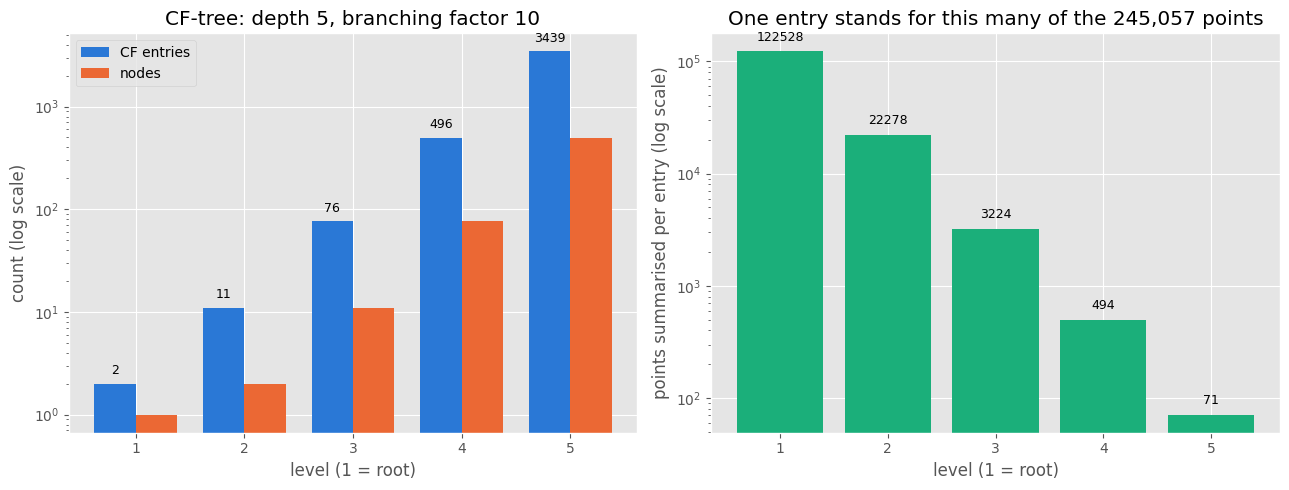

In [7]:
levels = sorted(birch.entries_per_level)
ent_counts = [birch.entries_per_level[l] for l in levels]
node_counts = [birch.nodes_per_level[l] for l in levels]
per_entry = [len(X) / birch.entries_per_level[l] for l in levels]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

w = 0.38
ax[0].bar([l - w / 2 for l in levels], ent_counts, width=w, color=blue, label='CF entries')
ax[0].bar([l + w / 2 for l in levels], node_counts, width=w, color=orange, label='nodes')
ax[0].set_yscale('log')
ax[0].set_xticks(levels)
ax[0].set_xlabel('level (1 = root)')
ax[0].set_ylabel('count (log scale)')
ax[0].set_title(f'CF-tree: depth {birch.depth}, branching factor {birch.branching_factor}')
ax[0].legend()
for l, c in zip(levels, ent_counts):
    ax[0].text(l - w / 2, c * 1.25, str(c), ha='center', fontsize=9)

ax[1].bar(levels, per_entry, color=green)
ax[1].set_yscale('log')
ax[1].set_xticks(levels)
ax[1].set_xlabel('level (1 = root)')
ax[1].set_ylabel('points summarised per entry (log scale)')
ax[1].set_title('One entry stands for this many of the 245,057 points')
for l, v in zip(levels, per_entry):
    ax[1].text(l, v * 1.25, f'{v:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## The leaf entries drawn over the data

This is the summarisation made visible. The grey points are the pixels, and each circle is one leaf
CF entry: it sits at $\vec{c} = \vec{LS}/N$ and its outline has radius $R = \sqrt{SS/N -
\lVert \vec{LS}/N \rVert^2}$, both read straight off the triple. The filled marker at the centre
has **area proportional to $N$** (with a small floor so single-point entries stay visible), so a large dot is an entry that swallowed many pixels.

The circles are drawn in a two-dimensional slice of a three-dimensional radius, so an entry can
look smaller than its outline where it extends into the third channel.

The right panel colours each entry by the fraction of its points that are skin, which is a check
that the entries are pure even though the label was never used: an entry is either almost all skin
or almost none, because at this threshold an entry is far smaller than the region where the two
classes meet.

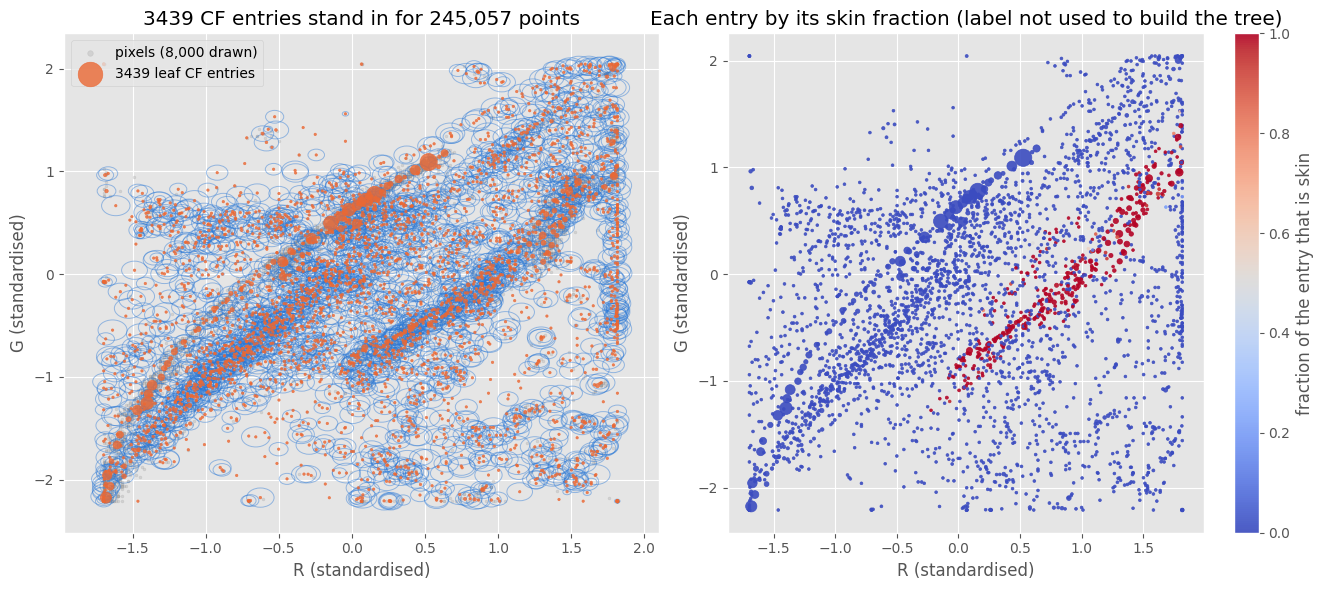

99.3% of leaf entries are more than 95% one class
weighted by size, those entries hold 99.7% of the pixels


In [8]:
entry_of_point = birch.nearest_entry(X)
skin_frac = np.zeros(n_leaf)
counts = np.bincount(entry_of_point, minlength=n_leaf).astype(float)
skin_counts = np.bincount(entry_of_point, weights=(y == 1).astype(float), minlength=n_leaf)
skin_frac = np.where(counts > 0, skin_counts / np.maximum(counts, 1), 0.0)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 6))
i, j = 2, 1

ax[0].scatter(Xp[:, i], Xp[:, j], color='#999999', s=4, alpha=0.25, label='pixels (8,000 drawn)')
for c, r in zip(birch.centroids, birch.radii):
    ax[0].add_patch(Circle((c[i], c[j]), r, fill=False, edgecolor=blue, alpha=0.45, lw=0.7))
ax[0].scatter(birch.centroids[:, i], birch.centroids[:, j], s=birch.N / birch.N.max() * 150 + 3,
              color=orange, alpha=0.8, label=f'{n_leaf} leaf CF entries')
ax[0].set_xlabel(feature_names[i] + ' (standardised)')
ax[0].set_ylabel(feature_names[j] + ' (standardised)')
ax[0].set_title(f'{n_leaf} CF entries stand in for {len(X):,} points')
ax[0].legend(markerscale=2, loc='upper left')

sc = ax[1].scatter(birch.centroids[:, i], birch.centroids[:, j],
                   s=birch.N / birch.N.max() * 150 + 4, c=skin_frac, cmap='coolwarm', alpha=0.9)
ax[1].set_xlabel(feature_names[i] + ' (standardised)')
ax[1].set_ylabel(feature_names[j] + ' (standardised)')
ax[1].set_title('Each entry by its skin fraction (label not used to build the tree)')
fig.colorbar(sc, ax=ax[1], label='fraction of the entry that is skin')

plt.tight_layout()
plt.show()

pure = ((skin_frac < 0.05) | (skin_frac > 0.95)).mean()
print(f'{pure * 100:.1f}% of leaf entries are more than 95% one class')
print(f'weighted by size, those entries hold {birch.N[(skin_frac < 0.05) | (skin_frac > 0.95)].sum() / len(X) * 100:.1f}% of the pixels')

## Two clusters, scored against the label

Every one of the 245,057 rows is sent to its nearest leaf entry and then to whichever of the two
final clusters that entry belongs to. `accuracy` maps each cluster to its majority true label and
counts the agreements, the same convention used in the other clustering notebooks here.

In [9]:
labels2 = birch.predict(X)
acc2, map2 = accuracy(labels2, y)

print('cluster sizes and composition')
for c in sorted(set(labels2)):
    members = y[labels2 == c]
    s = int((members == 1).sum())
    ns = int((members == 2).sum())
    print(f'  cluster {c}: {len(members):7,} pixels  skin {s:7,}  not-skin {ns:7,}  '
          f'purity {max(s, ns) / len(members):.3f}  -> called {"skin" if map2[c] == 1 else "not-skin"}')
print()
print(f'BIRCH with n_clusters=2: {acc2:.4f}')
print(f'majority-class baseline: {baseline:.4f}')

cluster sizes and composition
  cluster 0: 244,601 pixels  skin  50,859  not-skin 193,742  purity 0.792  -> called not-skin
  cluster 1:     456 pixels  skin       0  not-skin     456  purity 1.000  -> called not-skin

BIRCH with n_clusters=2: 0.7925
majority-class baseline: 0.7925


With two clusters BIRCH scores exactly the majority-class baseline. It has not found the skin/not-skin
split, and the reason is visible in the first figure: the classes are two long overlapping bands,
and BIRCH is built on a radius. `threshold` bounds a **sphere**, the $D_2$ used to merge is a
distance between centroids inflated by two radii, and neither has any way to prefer a long thin
group over a round one. Cutting an elongated cloud in half across its length is cheaper by that
measure than peeling off the narrow band that is the skin.

This is a real limitation of the method and not something a parameter fixes. The contribution of
the algorithm on this dataset is the one-pass summarisation and the scaling, not the accuracy.

The leaf entries themselves are pure, as the previous figure showed, so the information survives
the summarisation - it is the two-cluster global step that discards it. The next cell asks the
global step for more than two clusters and reads the accuracy off the same merge order.

  k=  2  accuracy 0.7925
  k=  3  accuracy 0.7925
  k=  4  accuracy 0.7925
  k=  5  accuracy 0.7925
  k=  6  accuracy 0.7925
  k=  8  accuracy 0.8125
  k= 10  accuracy 0.8125
  k= 12  accuracy 0.8385
  k= 14  accuracy 0.9645
  k= 16  accuracy 0.9686
  k= 20  accuracy 0.9686


  k= 25  accuracy 0.9771
  k= 30  accuracy 0.9843


  k= 40  accuracy 0.9843
  k= 50  accuracy 0.9850


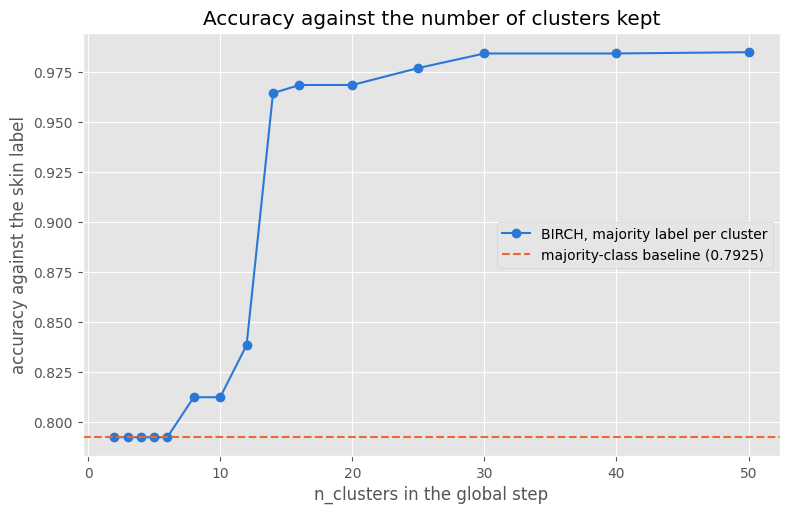


best of these: k=50 at 0.9850
more clusters means more freedom in the majority-label mapping, so this rises
on its own; it is not a like-for-like comparison with the k=2 number.


In [10]:
ks = [2, 3, 4, 5, 6, 8, 10, 12, 14, 16, 20, 25, 30, 40, 50]
accs = []
for k in ks:
    lab = birch.labels_for_k(k)[entry_of_point]
    a, _ = accuracy(lab, y)
    accs.append(a)
    print(f'  k={k:3d}  accuracy {a:.4f}')

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.plot(ks, accs, marker='o', color=blue, label='BIRCH, majority label per cluster')
ax.axhline(baseline, color=orange, ls='--', label=f'majority-class baseline ({baseline:.4f})')
ax.set_xlabel('n_clusters in the global step')
ax.set_ylabel('accuracy against the skin label')
ax.set_title('Accuracy against the number of clusters kept')
ax.legend()
plt.show()

k_best = ks[int(np.argmax(accs))]
print()
print(f'best of these: k={k_best} at {max(accs):.4f}')
print('more clusters means more freedom in the majority-label mapping, so this rises')
print('on its own; it is not a like-for-like comparison with the k=2 number.')

Accuracy stays flat at the baseline until about eight clusters, then climbs sharply. Once the
global step is allowed enough clusters, the merge order starts separating the narrow skin band from
the rest instead of splitting the big band down the middle.

The caveat matters: mapping each cluster to its majority label gives a larger $k$ more room, so part
of that rise is the scoring and not the clustering. With one cluster per leaf entry the score would
reach the purity of the entries themselves. The honest reading is that BIRCH's summary retains the
class structure, while its two-cluster global step does not recover it.

The next cell draws the assignments at $k = 2$ and at $k = 20$ beside the true labels.

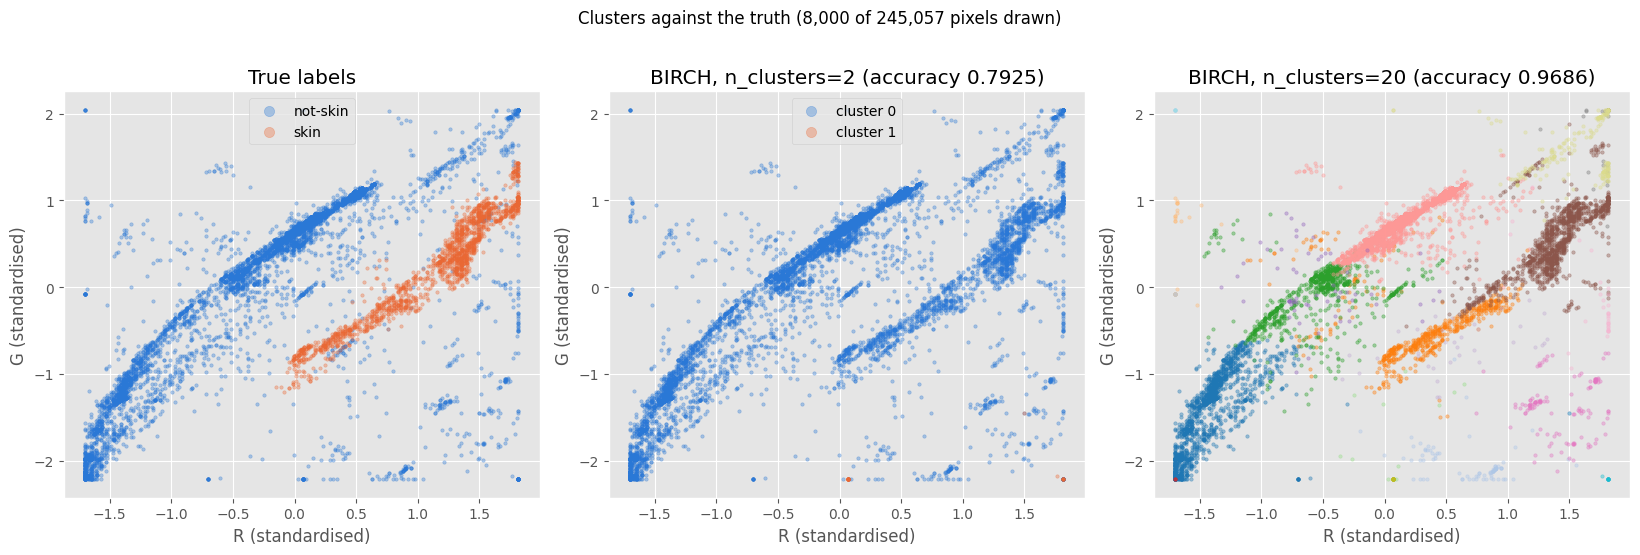

In [11]:
k_show = 20
labels_k = birch.labels_for_k(k_show)[entry_of_point]
acc_k, map_k = accuracy(labels_k, y)

lab2_p = labels2[plot_idx]
labk_p = labels_k[plot_idx]
i, j = 2, 1

fig, ax = plt.subplots(1, 3, figsize=(16.5, 5.4))

for label, color, name in [(2, blue, 'not-skin'), (1, orange, 'skin')]:
    m = yp == label
    ax[0].scatter(Xp[m, i], Xp[m, j], color=color, s=6, alpha=0.35, label=name)
ax[0].set_title('True labels')
ax[0].legend(markerscale=3)

for c in sorted(set(lab2_p)):
    m = lab2_p == c
    ax[1].scatter(Xp[m, i], Xp[m, j], color=colors[c], s=6, alpha=0.35, label=f'cluster {c}')
ax[1].set_title(f'BIRCH, n_clusters=2 (accuracy {acc2:.4f})')
ax[1].legend(markerscale=3)

cmap = plt.get_cmap('tab20')
for c in sorted(set(labk_p)):
    m = labk_p == c
    ax[2].scatter(Xp[m, i], Xp[m, j], color=cmap(c % 20), s=6, alpha=0.4)
ax[2].set_title(f'BIRCH, n_clusters={k_show} (accuracy {acc_k:.4f})')

for a in ax:
    a.set_xlabel(feature_names[i] + ' (standardised)')
    a.set_ylabel(feature_names[j] + ' (standardised)')
fig.suptitle('Clusters against the truth (8,000 of 245,057 pixels drawn)', y=1.02)
plt.tight_layout()
plt.show()

## Confusion matrices

Each cluster is called skin or not-skin by its majority label, and the counts are crossed against
the truth. The left panel is the two-cluster result, the right the twenty-cluster one, both over
all 245,057 pixels.

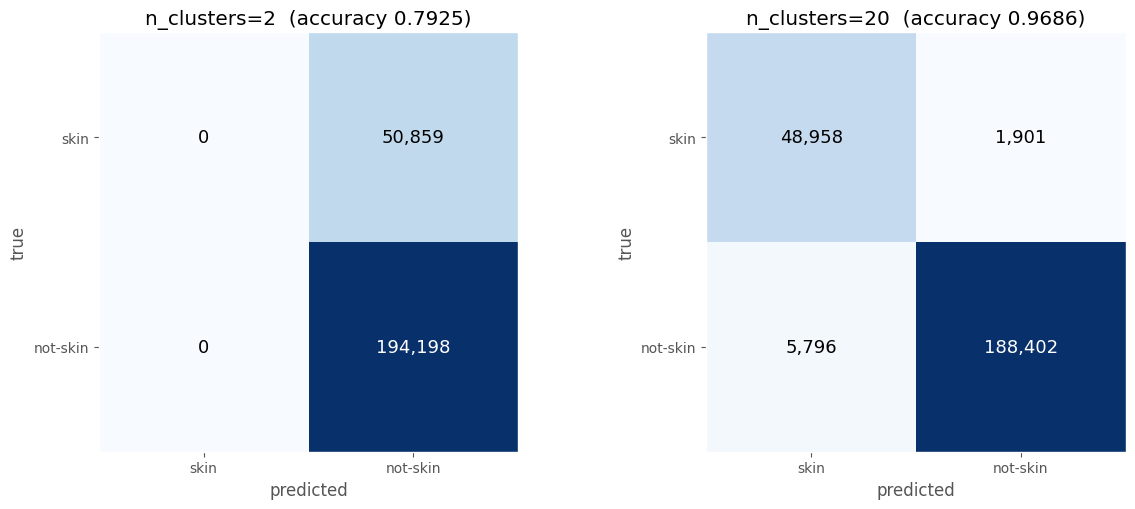

n_clusters=2 : every pixel is called not-skin, so the 50,859 skin pixels are all missed
n_clusters=20: skin recall 0.963, not-skin recall 0.970


In [12]:
def confusion(labels, mapping):
    pred = np.array([mapping[c] for c in labels])
    M = np.zeros((2, 2), dtype=int)
    for a, true_v in enumerate([1, 2]):
        for b, pred_v in enumerate([1, 2]):
            M[a, b] = int(((y == true_v) & (pred == pred_v)).sum())
    return M


fig, ax = plt.subplots(1, 2, figsize=(12.5, 5.2))
names = ['skin', 'not-skin']

for a, (M, ttl) in zip(ax, [(confusion(labels2, map2), f'n_clusters=2  (accuracy {acc2:.4f})'),
                            (confusion(labels_k, map_k), f'n_clusters={k_show}  (accuracy {acc_k:.4f})')]):
    a.imshow(M, cmap='Blues')
    a.set_xticks([0, 1]); a.set_xticklabels(names)
    a.set_yticks([0, 1]); a.set_yticklabels(names)
    a.set_xlabel('predicted')
    a.set_ylabel('true')
    a.set_title(ttl)
    a.grid(False)
    for r in range(2):
        for c in range(2):
            a.text(c, r, f'{M[r, c]:,}', ha='center', va='center',
                   color='white' if M[r, c] > M.max() / 2 else 'black', fontsize=13)

plt.tight_layout()
plt.show()

M2 = confusion(labels2, map2)
print('n_clusters=2 : every pixel is called not-skin, so the', f'{int(M2[0].sum()):,}',
      'skin pixels are all missed')
Mk = confusion(labels_k, map_k)
print(f'n_clusters={k_show}: skin recall {Mk[0, 0] / Mk[0].sum():.3f}, '
      f'not-skin recall {Mk[1, 1] / Mk[1].sum():.3f}')

## The threshold parameter

`threshold` is the radius cap on a leaf entry, and it is the single knob controlling how hard the
data is compressed. A small threshold means entries must stay tight, so there are many of them and
the tree is large and detailed. A large threshold lets one entry swallow a wide region, so there are
few of them and the summary is coarse.

The cell rebuilds the whole tree over all 245,057 rows for each threshold and records the number of
leaf entries, the wall-clock time of the pass, and the accuracy after the global step at both
$k = 2$ and $k = 20$.

  threshold 0.08: depth 5  leaf entries   5195  compression     47.2x  pass   1.8s  acc(k=2) 0.7925  acc(k=20) 0.9746


  threshold 0.10: depth 5  leaf entries   3439  compression     71.3x  pass   3.1s  acc(k=2) 0.7925  acc(k=20) 0.9686


  threshold 0.15: depth 4  leaf entries   1474  compression    166.3x  pass  13.5s  acc(k=2) 0.7925  acc(k=20) 0.9726


  threshold 0.20: depth 4  leaf entries    805  compression    304.4x  pass  13.0s  acc(k=2) 0.7925  acc(k=20) 0.9674


  threshold 0.30: depth 3  leaf entries    354  compression    692.3x  pass   9.7s  acc(k=2) 0.7925  acc(k=20) 0.9702


  threshold 0.50: depth 3  leaf entries     92  compression   2663.7x  pass   8.2s  acc(k=2) 0.7925  acc(k=20) 0.9647


  threshold 0.80: depth 2  leaf entries     36  compression   6807.1x  pass   6.2s  acc(k=2) 0.7925  acc(k=20) 0.9796


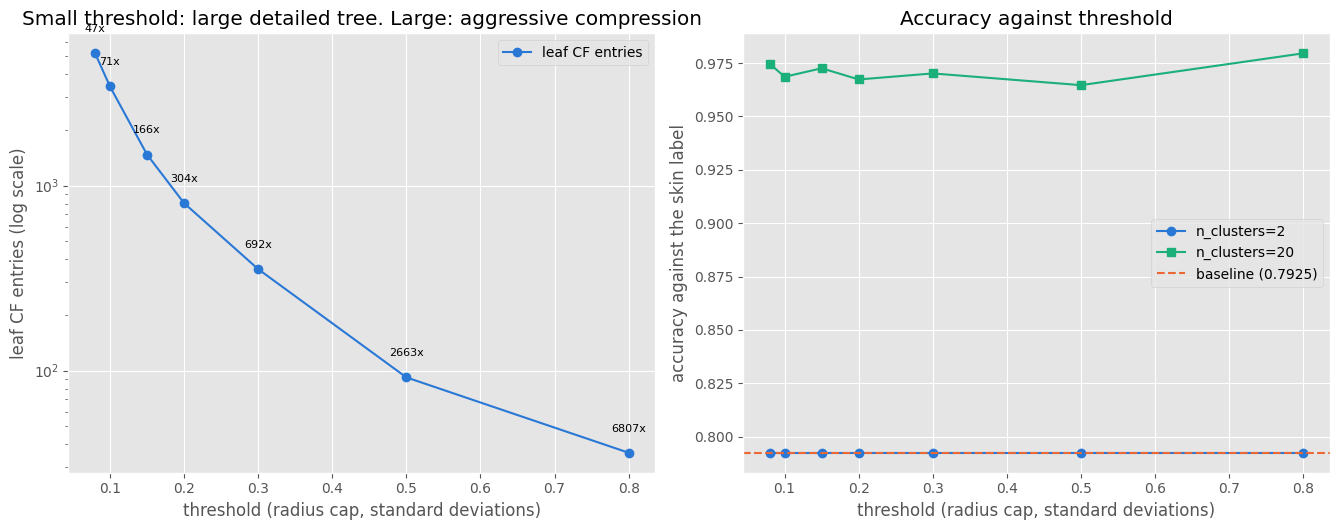

In [13]:
thresholds = [0.08, 0.1, 0.15, 0.2, 0.3, 0.5, 0.8]
sweep_leaves, sweep_time, sweep_acc2, sweep_acck = [], [], [], []

for thr in thresholds:
    t0 = time.time()
    b = BIRCH(threshold=thr, branching_factor=10)
    b.build(X.tolist())
    b.collect()
    el = time.time() - t0
    b.global_step()
    ent = b.nearest_entry(X)
    L = len(b.N)
    a2, _ = accuracy(b.labels_for_k(min(2, L))[ent], y)
    ak, _ = accuracy(b.labels_for_k(min(k_show, L))[ent], y)
    sweep_leaves.append(L)
    sweep_time.append(el)
    sweep_acc2.append(a2)
    sweep_acck.append(ak)
    print(f'  threshold {thr:4.2f}: depth {b.depth}  leaf entries {L:6d}  '
          f'compression {len(X) / L:8.1f}x  pass {el:5.1f}s  acc(k=2) {a2:.4f}  acc(k={k_show}) {ak:.4f}')

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))

ax[0].plot(thresholds, sweep_leaves, marker='o', color=blue, label='leaf CF entries')
ax[0].set_yscale('log')
ax[0].set_xlabel('threshold (radius cap, standard deviations)')
ax[0].set_ylabel('leaf CF entries (log scale)')
ax[0].set_title('Small threshold: large detailed tree. Large: aggressive compression')
ax[0].legend()
for t_, l_ in zip(thresholds, sweep_leaves):
    ax[0].text(t_, l_ * 1.3, f'{len(X) // l_}x', ha='center', fontsize=8)

ax[1].plot(thresholds, sweep_acc2, marker='o', color=blue, label='n_clusters=2')
ax[1].plot(thresholds, sweep_acck, marker='s', color=green, label=f'n_clusters={k_show}')
ax[1].axhline(baseline, color=orange, ls='--', label=f'baseline ({baseline:.4f})')
ax[1].set_xlabel('threshold (radius cap, standard deviations)')
ax[1].set_ylabel('accuracy against the skin label')
ax[1].set_title('Accuracy against threshold')
ax[1].legend()

plt.tight_layout()
plt.show()

The number of leaf entries falls by orders of magnitude as the threshold grows, and the single pass
gets slightly faster with it, because a shallower tree with fewer entries per node is quicker to
descend.

The two-cluster accuracy is flat at the baseline across the whole range, which is the same
limitation as before and not something the threshold reaches. The twenty-cluster accuracy does
depend on it: too coarse a summary and the leaf entries straddle the boundary between the classes,
at which point no global step can separate them, because the information was thrown away in the
pass.

## Scaling

The last claim to check is the cost. The cell runs the same single pass on growing prefixes of the
shuffled data and times it. The left panel is wall-clock time against the number of points, with a
straight line through the origin fitted to the largest run for comparison; the right panel is the
number of leaf entries retained against the number of points summarised.

The dashed curve on the left is $O(n^2)$ scaled to pass through the smallest run, which is the shape
Mean Shift follows on the same data. At 245,057 points that curve is off the top of the panel by a
wide margin.

  n =   2,000  pass  0.06s  leaf entries   330  compression    6.1x


  n =  10,000  pass  1.11s  leaf entries   829  compression   12.1x


  n =  30,000  pass  1.54s  leaf entries  1457  compression   20.6x


  n =  60,000  pass  3.12s  leaf entries  1984  compression   30.2x


  n = 120,000  pass  7.72s  leaf entries  2618  compression   45.8x


  n = 245,057  pass 13.19s  leaf entries  3439  compression   71.3x


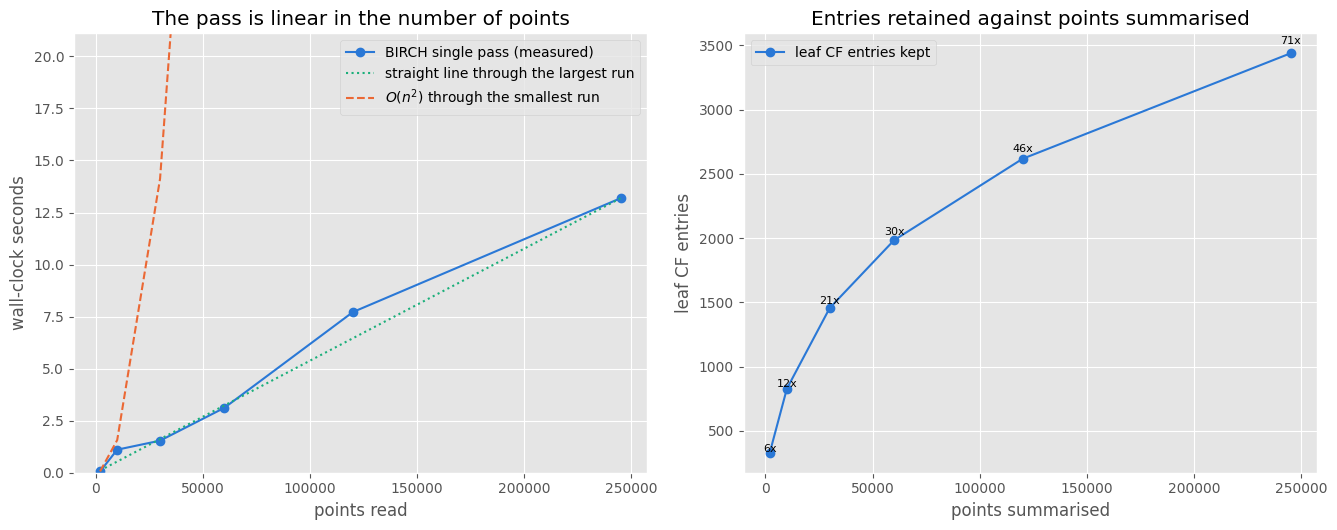


time per point at n=245,057: 53.84 microseconds
the O(n^2) curve would predict 942 s for the same run


In [14]:
sizes = [2000, 10000, 30000, 60000, 120000, len(X)]
scale_time, scale_leaves = [], []

for n in sizes:
    t0 = time.time()
    b = BIRCH(threshold=0.1, branching_factor=10)
    b.build(X[:n].tolist())
    b.collect()
    el = time.time() - t0
    scale_time.append(el)
    scale_leaves.append(len(b.N))
    print(f'  n = {n:7,}  pass {el:5.2f}s  leaf entries {len(b.N):5d}  '
          f'compression {n / len(b.N):6.1f}x')

sizes = np.array(sizes, dtype=float)
scale_time = np.array(scale_time)
scale_leaves = np.array(scale_leaves)

linear = scale_time[-1] / sizes[-1] * sizes
quad = scale_time[0] * (sizes / sizes[0]) ** 2

fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))

ax[0].plot(sizes, scale_time, marker='o', color=blue, label='BIRCH single pass (measured)')
ax[0].plot(sizes, linear, color=green, ls=':', label='straight line through the largest run')
ax[0].plot(sizes, quad, color=orange, ls='--', label='$O(n^2)$ through the smallest run')
ax[0].set_ylim(0, scale_time.max() * 1.6)
ax[0].set_xlabel('points read')
ax[0].set_ylabel('wall-clock seconds')
ax[0].set_title('The pass is linear in the number of points')
ax[0].legend()

ax[1].plot(sizes, scale_leaves, marker='o', color=blue, label='leaf CF entries kept')
ax[1].set_xlabel('points summarised')
ax[1].set_ylabel('leaf CF entries')
ax[1].set_title('Entries retained against points summarised')
ax[1].legend()
for n_, l_ in zip(sizes, scale_leaves):
    ax[1].text(n_, l_ * 1.02, f'{n_ / l_:.0f}x', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

print()
print(f'time per point at n={int(sizes[-1]):,}: {scale_time[-1] / sizes[-1] * 1e6:.2f} microseconds')
print(f'the O(n^2) curve would predict {quad[-1]:.0f} s for the same run')

## Summary

The whole dataset, 245,057 pixels, was clustered. It was read once. At `threshold=0.1` and
`branching_factor=10` the CF-tree came out with the depth, leaf count and compression ratio printed
above, and at no point did memory hold more than a few thousand five-number triples in place of the
245,057 rows.

What the notebook shows:

- The CF triple $(N, \vec{LS}, SS)$ is sufficient. Centroid, radius, diameter and the inter-cluster
  distance all follow from it exactly, verified numerically against the definitions, so the points
  can be discarded as they are read.
- Additivity, $CF_1 + CF_2 = (N_1 + N_2, \vec{LS}_1 + \vec{LS}_2, SS_1 + SS_2)$, is what lets a
  point be absorbed, a node summarise its children, and two clusters merge, all by addition.
- The cost is linear. The measured time per point is flat across two orders of magnitude of
  dataset size, against the $3.0 \times 10^{10}$ pairwise distances per pass that the same data
  would cost a method comparing all points against all points - the reason
  `mean_shift_from_scratch.ipynb` runs on 800 rows and this one runs on all 245,057.
- The `threshold` sets the compression directly, trading tree size against how much detail the
  summary keeps.

What it does not show is accuracy. With two clusters BIRCH scores the majority-class baseline of
0.7925 and nothing above it, because the skin and not-skin classes are long overlapping bands and
every decision the algorithm makes - the radius cap, the split seeds, the merge distance - is
phrased in terms of a radius around a centroid. The leaf entries are almost all pure, so the
summarisation itself does not lose the classes; the two-cluster global step is what fails to
recover them, and allowing it more clusters recovers most of the structure, with the caveat that
the majority-label scoring flatters larger $k$.